In [18]:
# Load dataset
import pandas as pd
import numpy as np

df_raw = pd.read_csv('hwg_metadata.csv', skiprows=4)

# drop subject_id column
df_raw.drop(columns=['subject_id'], inplace=True)

# Create a height_m column
df_raw['height_m'] = df_raw['height_cm'] / 100

# Create a bmi column
df_raw['bmi'] = df_raw['weight_kg'] / (df_raw['height_m'] ** 2)

# Round bmi to 2 decimal places
df_raw['bmi'] = df_raw['bmi'].round(2)

# Create an is_obese column
df_raw['is_obese'] = np.where(df_raw['bmi'] >= 30, 1, 0)

df = df_raw.copy()

df.head()

,gender,height_cm,weight_kg,height_m,bmi,is_obese
0,female,160.00,92.4,1.6000,36.09,1
1,female,175.75,102.8,1.7575,33.28,1
2,male,174.80,106.9,1.7480,34.99,1
3,male,181.50,111.8,1.8150,33.94,1
4,female,161.60,93.0,1.6160,35.61,1


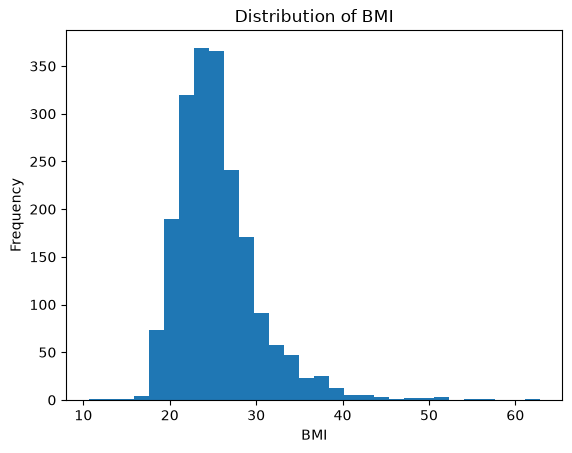

In [9]:
# Show histogram of bmi
import matplotlib.pyplot as plt

plt.hist(df_raw['bmi'], bins=30)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Distribution of BMI')
plt.show()

In [10]:
# Show is_obese value counts
df_raw['is_obese'].value_counts()

is_obese
0    1756
1     262
Name: count, dtype: int64

In [11]:
# Create a prediction model based on weight

df['predicted_is_obese'] = np.where(df_raw['weight_kg'] >= 100, 1, 0)

df

,gender,height_cm,weight_kg,height_m,bmi,is_obese,predicted_is_obese
0,female,160.00,92.40,1.6000,36.09,1,0
1,female,175.75,102.80,1.7575,33.28,1,1
2,male,174.80,106.90,1.7480,34.99,1,1
3,male,181.50,111.80,1.8150,33.94,1,1
4,female,161.60,93.00,1.6160,35.61,1,0
...,...,...,...,...,...,...,...
2013,female,175.00,103.25,1.7500,33.71,1,1
2014,male,169.50,103.90,1.6950,36.16,1,1
2015,male,180.20,111.90,1.8020,34.46,1,1
2016,male,168.00,102.60,1.6800,36.35,1,1


[[1736   20]
 [ 142  120]]


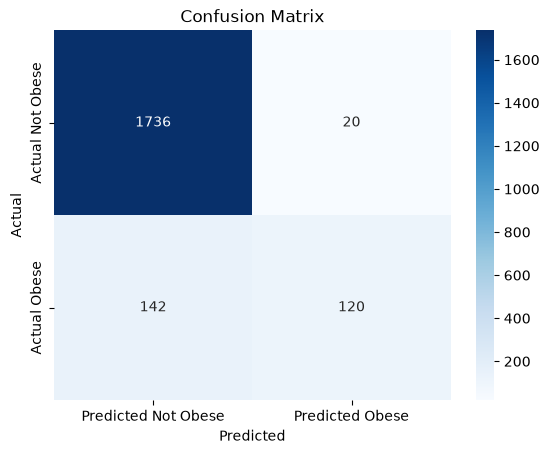

In [15]:
# Create a confusion matrix for is_obese vs predicted_is_obese
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['is_obese'], df['predicted_is_obese'])
print(cm)

# Print a pretty version of the confusion matrix
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Not Obese', 'Predicted Obese'], yticklabels=['Actual Not Obese', 'Actual Obese'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# Calculate accuracy, precision, recall, and F1 score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(df['is_obese'], df['predicted_is_obese'])
precision = precision_score(df['is_obese'], df['predicted_is_obese'])
recall = recall_score(df['is_obese'], df['predicted_is_obese'])
f1 = f1_score(df['is_obese'], df['predicted_is_obese'])

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Accuracy: 0.92
Precision: 0.86
Recall: 0.46
F1 Score: 0.60


AUC: 0.72


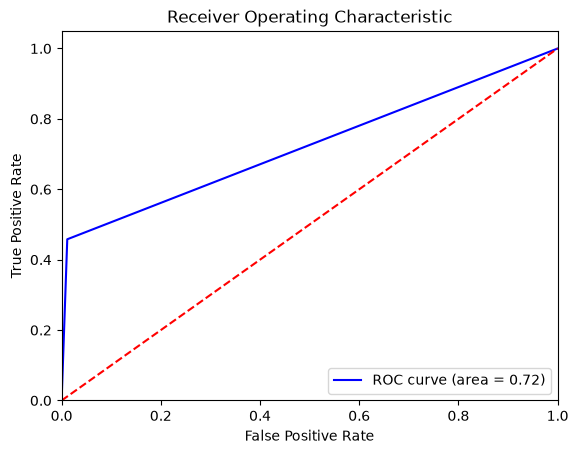

In [17]:
# Print a ROC curve and AUC score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(df['is_obese'], df['predicted_is_obese'])
roc_auc = auc(fpr, tpr)

print(f'AUC: {roc_auc:.2f}')

# Print a roc curve
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()
